### Jeevadharan G - 24BAD046

In [6]:
import os
import tarfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [8]:
extract_dir = "flowers17"

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

    with tarfile.open(dataset_file, "r:gz") as tar:
        tar.extractall(extract_dir)

print("Dataset extracted.")

Dataset extracted.


In [9]:
os.listdir(extract_dir)

[]

In [10]:
class_names = [
    "daffodil",
    "snowdrop",
    "lilyvalley",
    "bluebell",
    "crocus",
    "iris",
    "tigerlily",
    "tulip",
    "fritillary",
    "sunflower",
    "daisy",
    "coltsfoot",
    "dandelion",
    "cowslip",
    "buttercup",
    "windflower",
    "pansy"
]

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)

Number of classes: 17


In [12]:
image_dir = os.path.join(extract_dir, "jpg")

images = []
labels = []

for class_id in range(NUM_CLASSES):

    start_index = class_id * 80 + 1
    end_index = start_index + 80

    for image_id in range(start_index, end_index):

        filename = f"image_{image_id:04d}.jpg"
        filepath = os.path.join(image_dir, filename)

        image = Image.open(filepath).convert("RGB")

        images.append(np.array(image))
        labels.append(class_id)

print("Total images:", len(images))
print("Total labels:", len(labels))

FileNotFoundError: [Errno 2] No such file or directory: 'flowers17\\jpg\\image_0001.jpg'

In [ ]:
images = np.array(images, dtype=object)
labels = np.array(labels)

print("Images:", len(images))
print("Labels:", labels.shape)

Images: 1360
Labels: (1360,)


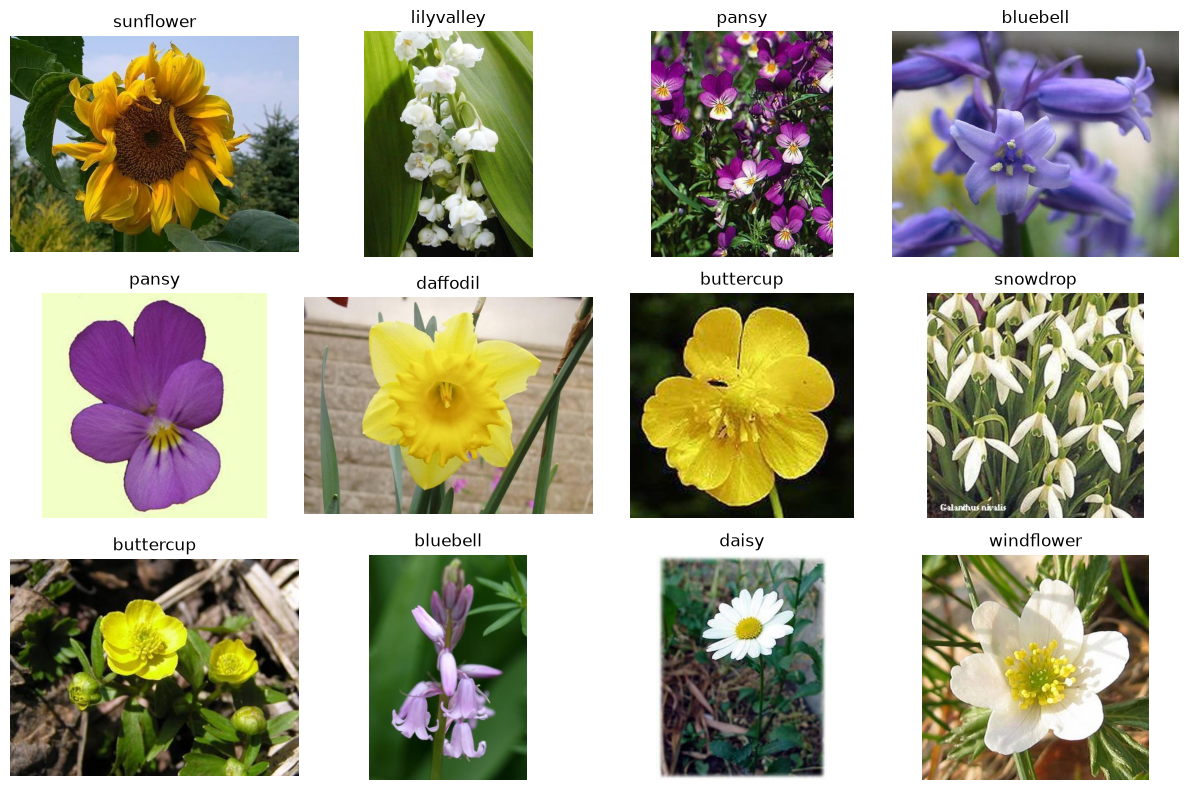

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):

    index = np.random.randint(0, len(images))

    plt.subplot(3, 4, i + 1)
    plt.imshow(images[index])
    plt.title(class_names[labels[index]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [ ]:
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

Training: 952
Validation: 204
Testing: 204


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16

In [ ]:
def preprocess_image(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)

    return image, label

In [ ]:
def image_generator(images, labels):
    for image, label in zip(images, labels):
        yield image, label

In [ ]:
train_ds = tf.data.Dataset.from_generator(
    lambda: image_generator(X_train, y_train),
    output_signature=(
        tf.TensorSpec(shape=(None, None, 3), dtype=tf.uint8),
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
)

val_ds = tf.data.Dataset.from_generator(
    lambda: image_generator(X_val, y_val),
    output_signature=(
        tf.TensorSpec(shape=(None, None, 3), dtype=tf.uint8),
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
)

test_ds = tf.data.Dataset.from_generator(
    lambda: image_generator(X_test, y_test),
    output_signature=(
        tf.TensorSpec(shape=(None, None, 3), dtype=tf.uint8),
        tf.TensorSpec(shape=(), dtype=tf.int64)
    )
)

W0000 00:00:1786968194.254823   24524 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [ ]:
train_ds = train_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
train_ds = (
    train_ds
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [ ]:
base_model.trainable = False

In [ ]:
print("ResNet50 trainable:", base_model.trainable)

ResNet50 trainable: False


In [ ]:
model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.4),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [ ]:
layers.Dense(17, activation="softmax")

<Dense name=dense_2, built=False>

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,852,177 (90.99 MB)

 Trainable params: 264,465 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


/run/media/nishanth/NP/KCT/24ADI006L-DL-24BAD405/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1786968200.090266   24832 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


     60/Unknown 47s 696ms/step - accuracy: 0.4874 - loss: 1.7480

/run/media/nishanth/NP/KCT/24ADI006L-DL-24BAD405/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 906ms/step - accuracy: 0.4874 - loss: 1.7480 - val_accuracy: 0.8873 - val_loss: 0.4939
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8277 - loss: 0.5780 - val_accuracy: 0.9118 - val_loss: 0.3242
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9128 - loss: 0.3089 - val_accuracy: 0.9363 - val_loss: 0.2032
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9506 - loss: 0.1997 - val_accuracy: 0.9363 - val_loss: 0.1990
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9643 - loss: 0.1527 - val_accuracy: 0.9314 - val_loss: 0.1771
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9653 - loss: 0.1218 - val_accuracy: 0.9461 - val_loss: 0.1523
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 61s 996ms/step - accuracy: 0.9811 - loss: 0.0939 - val_accuracy: 0.9510 - val_loss: 0.1441
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 990ms/step - accuracy: 0.9800 - loss: 0.0832 - val_accuracy: 0.9510 - val_loss: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("\nTest Loss:", test_loss)
print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 738ms/step - accuracy: 0.9412 - loss: 0.1829

Test Loss: 0.18292556703090668
Test Accuracy: 94.12%


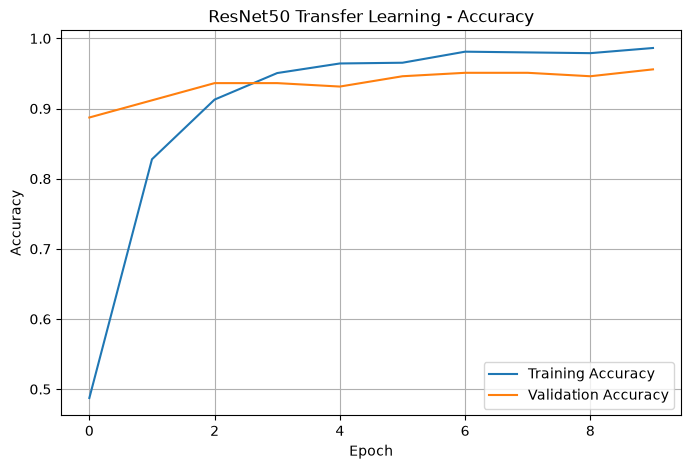

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ResNet50 Transfer Learning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

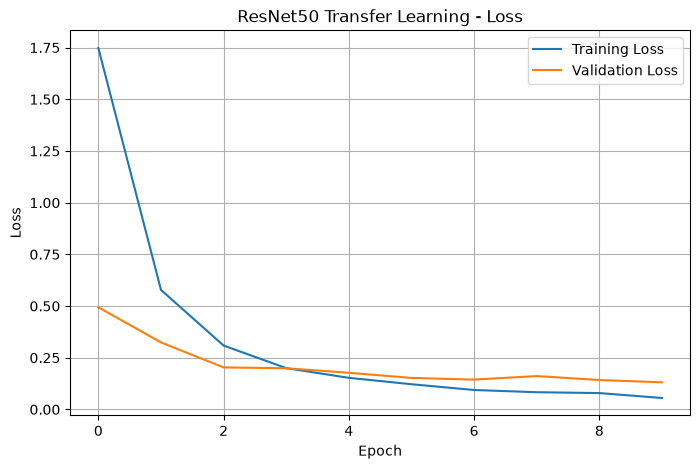

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ResNet50 Transfer Learning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
predictions = model.predict(test_ds)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 828ms/step


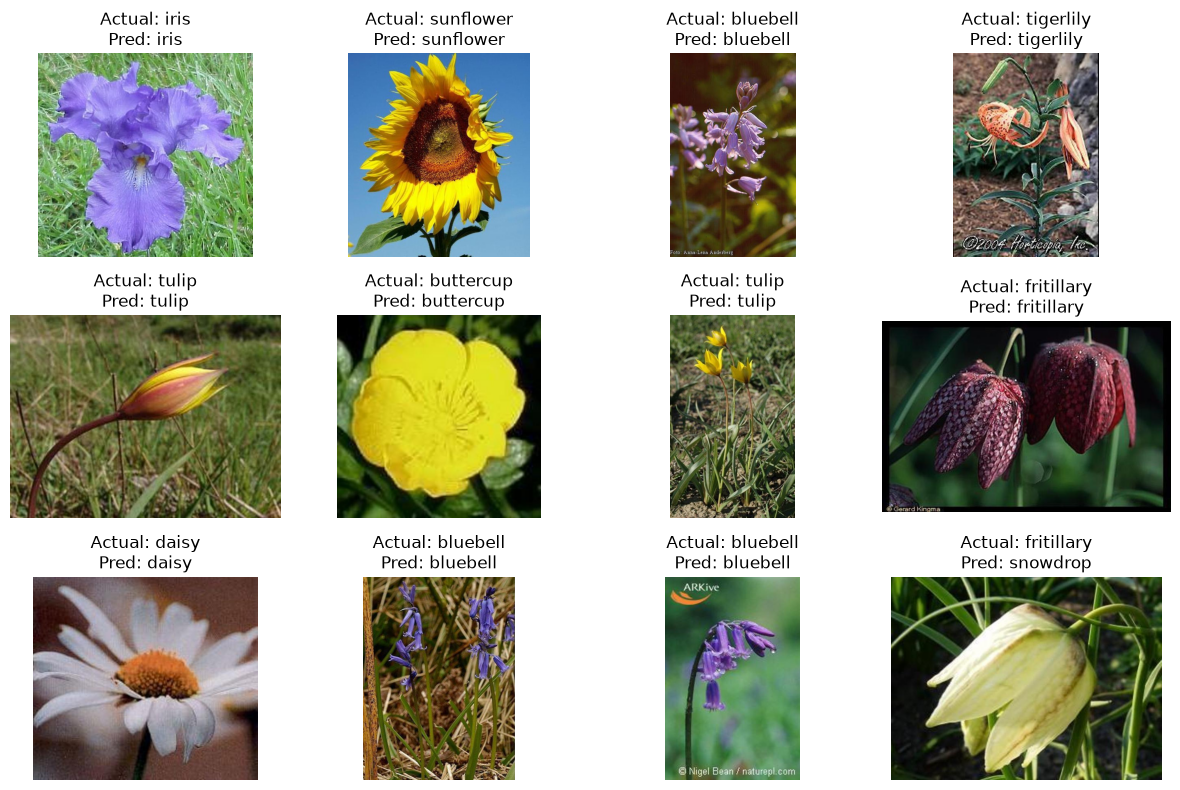

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):

    image = X_test[i]

    actual = y_test[i]

    predicted = predicted_classes[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {class_names[actual]}\n"
        f"Pred: {class_names[predicted]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
base_model.trainable = True

In [ ]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
trainable_layers = sum(
    layer.trainable
    for layer in base_model.layers
)

print(
    "Trainable ResNet layers:",
    trainable_layers
)

Trainable ResNet layers: 20


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9632 - loss: 0.1092 - val_accuracy: 0.9461 - val_loss: 0.1137
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9821 - loss: 0.0665 - val_accuracy: 0.9510 - val_loss: 0.1133
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9905 - loss: 0.0419 - val_accuracy: 0.9510 - val_loss: 0.1107
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9958 - loss: 0.0377 - val_accuracy: 0.9510 - val_loss: 0.1075
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9947 - loss: 0.0371 - val_accuracy: 0.9608 - val_loss: 0.1042


In [ ]:
fine_test_loss, fine_test_accuracy = model.evaluate(
    test_ds
)

print(
    f"Fine-tuned Test Accuracy: "
    f"{fine_test_accuracy * 100:.2f}%"
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 844ms/step - accuracy: 0.9412 - loss: 0.1230
Fine-tuned Test Accuracy: 94.12%


In [ ]:
model.save(
    "flowers17_resnet50_transfer_learning.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
import torch
from transformers import pipeline
from PIL import Image

print("PyTorch version:", torch.__version__)

device = 0 if torch.cuda.is_available() else -1

hf_classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224",
    device=device
)

sample_image = Image.fromarray(X_test[0])

results = hf_classifier(sample_image)

print("Actual TF Flowers class:")
print(class_names[int(y_test[0])])

print("\nHugging Face top-5 predictions:")

for result in results[:5]:
    print(
        f"{result['label']}: "
        f"{result['score']:.4f}"
    )

PyTorch version: 2.13.0+cu130


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 17397.25it/s]


Actual TF Flowers class:
iris

Hugging Face top-5 predictions:
picket fence, paling: 0.0176
pole: 0.0129
chambered nautilus, pearly nautilus, nautilus: 0.0098
baseball: 0.0085
echidna, spiny anteater, anteater: 0.0073
